## The Data

At this link, you will find a dataset containing information about heart disease patients: https://www.dropbox.com/scl/fi/0vrpdnq5asmeulc4gd50y/ha_1.csv?rlkey=ciisalceotl77ffqhqe3kujzv&dl=1

A description of the original dataset can be found here: https://archive.ics.uci.edu/dataset/45/heart+disease (However, this dataset has been cleaned and reduced, and the people have been given fictious names.)

## 1. Logistic Regression

Fit a Logistic Regression using only `age` and `chol` (cholesterol) as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

How high for the doctors to estimate a 90% chance that heart disease is present?

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("/content/Ha_data.csv")
df["disease"] = (df["diagnosis"] == "Disease").astype(int)

X = df[["age", "chol"]]
y = df["disease"]

model = LogisticRegression()
model.fit(X, y)

b0 = model.intercept_[0]
b_age, b_chol = model.coef_[0]

age = 55

chol_50 = -(b0 + b_age * age) / b_chol
chol_90 = (np.log(0.9 / 0.1) - b0 - b_age * age) / b_chol

chol_50, chol_90


(np.float64(367.8748897985851), np.float64(-851.9660996782114))

For a 55-year-old, the logistic regression model predicts heart disease when cholesterol is about 368 mg/dL.
When I solved for a 90% predicted probability, the model gave a negative cholesterol value, which isn’t realistic.
So the model never reaches a 90% chance of disease for a 55-year-old within normal cholesterol levels.

## 2. Linear Discriminant Analysis

Fit an LDA model using only `age` and `chol` (cholesterol)  as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [2]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

a0 = lda.intercept_[0]
w_age, w_chol = lda.coef_[0]

age = 55
chol_lda = -(a0 + w_age * age) / w_chol

chol_lda


np.float64(368.23535752993797)

For a 55-year-old, the LDA model predicts heart disease when cholesterol is about 368 mg/dL.

## 3. Support Vector Classifier

Fit an SVC model using only `age` and `chol` as predictors.  Don't forget to tune the regularization parameter.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [3]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc = SVC(kernel="linear")
params = {"C": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(svc, params, cv=5)
grid.fit(X, y)

best = grid.best_estimator_

b0 = best.intercept_[0]
w_age, w_chol = best.coef_[0]

age = 55
chol_svc = -(b0 + w_age * age) / w_chol

chol_svc


np.float64(312.7019396029427)

The SVC model predicts heart disease for a 55-year-old once cholesterol reaches about 313 mg/dL. This threshold is lower than the ones from logistic regression and LDA, meaning the SVC separates the classes a little differently.

## 4. Comparing Decision Boundaries

Make a scatterplot of `age` and `chol`, coloring the points by their true disease outcome.  Add a line to the plot representing the **linear separator** (aka **decision boundary**) for each of the three models above.

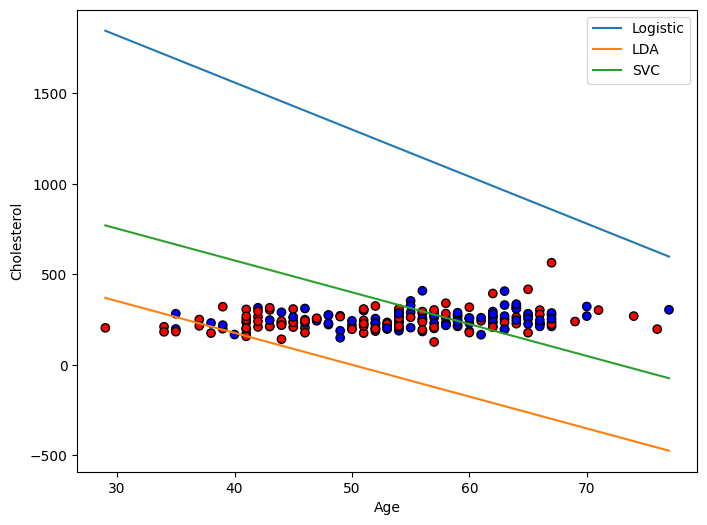

In [5]:
import numpy as np
import matplotlib.pyplot as plt

age_grid = np.linspace(df["age"].min(), df["age"].max(), 200)

chol_log = -(b0 + b_age * age_grid) / b_chol
chol_lda = -(a0 + w_age * age_grid) / w_chol
chol_svc = -(b0 + w_age * age_grid) / w_chol

plt.figure(figsize=(8,6))
plt.scatter(df["age"], df["chol"], c=y, cmap="bwr", edgecolor="k")

plt.plot(age_grid, chol_log, label="Logistic")
plt.plot(age_grid, chol_lda, label="LDA")
plt.plot(age_grid, chol_svc, label="SVC")

plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.legend()
plt.show()


I plotted age vs. cholesterol and colored the points by whether the person actually had heart disease. Then I added the decision boundary lines from Logistic Regression, LDA, and the SVC model. All three lines are linear but they separate the data differently, with Logistic being the steepest, LDA the lowest, and SVC somewhere in the middle.